# View Train Data

In [1]:
import pickle

import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from networks import PrimalNetEndToEnd  # make sure this is importable
# from gep_config_parser import parse_config  # only if you really need it

from gep_config_parser import parse_config

In [2]:
data_path = f"data/GEP_data/sample_duration:876_N:B-G-F_G:B2-G2-F2_L:L3.pkl"
data = pickle.load(open(data_path, 'rb'))

input_data = parse_config("configs/config.toml") # Reads the input data using config.toml's experiment.inputs.data path.

gep_ed_data = input_data["experiment"]["experiments"][0]

In [4]:
gep_ed_data

{'representative_period_weight': 1,
 'value_of_lost_load': 10.0,
 'ramping_value': 0.2,
 'demand_data':        Country  Time     Demand_MW
 0          AUS     1   4464.841992
 1          AUS     2   4124.826130
 2          AUS     3   3816.906161
 3          AUS     4   3526.037135
 4          AUS     5   3444.794407
 ...        ...   ...           ...
 175195     UKI  8756  35530.306849
 175196     UKI  8757  32133.512065
 175197     UKI  8758  28620.704825
 175198     UKI  8759  25327.448038
 175199     UKI  8760  23188.078573
 
 [175200 rows x 3 columns],
 'generation_data':     Technology Country  InvCost_kEUR_MW_year  VarCost_kEUR_per_MWh  UnitCap_MW
 0         Coal     BLK                 33.75                0.1500         400
 1         Coal     CZE                 33.75                0.1500         400
 2         Coal     GER                 33.75                0.1500         400
 3         Coal     IRE                 33.75                0.1500         400
 4         Coal 

In [5]:


countries = ["GER", "BEL", "FRA"]
dem = gep_ed_data["demand_data"]
ava = gep_ed_data["generation_availability_data"]

dem3 = dem[dem["Country"].isin(countries)]
ava3 = ava[ava["Country"].isin(countries)].copy()

# What you asked for: mean/std
dem_stats = dem3.groupby("Country")["Demand_MW"].agg(["mean","std","min","max"])
ava_stats = ava3.groupby(["Country","Technology"])["Availability_pu"].agg(
    ["mean","std","min","max", ("zero_frac", lambda s: (s <= 1e-6).mean())])
print("DEMAND (MW):\n", dem_stats, "\n")
print("AVAILABILITY (pu):\n", ava_stats, "\n")

# The two diagnostics that decide whether Gaussian sampling is even valid:
dem_w = dem3.pivot(index="Time", columns="Country", values="Demand_MW")
dem_w.columns = [f"D_{c}" for c in dem_w.columns]
ava3["var"] = "A_" + ava3["Country"] + "_" + ava3["Technology"]
ava_w = ava3.pivot(index="Time", columns="var", values="Availability_pu")
joint = dem_w.join(ava_w, how="inner")
print("Cross-correlation of the joint (D,A) vector:\n", joint.corr().round(2))

DEMAND (MW):
                  mean           std           min           max
Country                                                        
BEL       5608.193157   1336.536030   2403.698760   8890.113738
FRA      33967.269036  11683.933037   9494.393648  71931.625840
GER      43911.986410  11190.563663  19294.266848  67462.984974 

AVAILABILITY (pu):
                         mean       std    min    max  zero_frac
Country Technology                                             
BEL     SunPV       0.124312  0.195611  0.000  0.833   0.497374
        WindOff     0.540528  0.247773  0.000  0.991   0.008333
        WindOn      0.297726  0.220202  0.000  0.974   0.000799
FRA     SunPV       0.146185  0.202664  0.000  0.815   0.468721
        WindOff     0.481749  0.277990  0.000  0.991   0.004909
        WindOn      0.286956  0.168061  0.014  0.918   0.000000
GER     SunPV       0.122620  0.182642  0.000  0.813   0.482420
        WindOff     0.503661  0.275089  0.000  0.992   0.001712
    

## CHECK the GEP to obtain Training Data

In [1]:
import pickle, os, glob
import numpy as np
import pandas as pd

DIR = "data/GEP_for_training"

# --- load manifest + all instances ---
with open(os.path.join(DIR, "manifest.pkl"), "rb") as f:
    manifest = pickle.load(f)

paths = sorted(glob.glob(os.path.join(DIR, "gep_instance_*.pkl")))
instances = []
for p in paths:
    with open(p, "rb") as f:
        instances.append(pickle.load(f))
print(f"Loaded {len(instances)} instances\n")

# --- what attributes does a GEPProblemSet actually expose? (run once) ---
print("Attributes on instance 0:")
print([a for a in vars(instances[0]).keys() if not a.startswith("_")])
print()

Loaded 14 instances

Attributes on instance 0:
['DTYPE', 'DEVICE', 'args', 'sample_duration', 'T', 'G', 'L', 'N', 'num_g', 'num_l', 'num_n', 'pDemand', 'pGenAva', 'pVOLL', 'pWeight', 'pRamping', 'pInvCost', 'pVarCost', 'pUnitCap', 'pExpCap', 'pImpCap', 'n_var_per_t', 'n_ineq_per_t', 'n_eq_per_t', 'time_ranges', 'n_inv_vars', 'n_prod_vars', 'n_line_vars', 'n_md_vars', 'neq', 'nineq', 'ydim', 'node_to_gen_mask', 'lineflow_mask', 'obj_coeff', 'eq_rhs', 'ineq_rhs', 'X', 'xdim']



In [2]:
# --- 1. Manifest overview: the regime knobs per instance ---
rows = []
for m in manifest:
    rows.append({
        "id": m["instance_id"],
        "horizon": m["horizon"],
        "demand_scale": m["demand_scale"],
        "node_mult": str(m["node_multipliers"]),
        "cinv_perturb": m["cinv_perturb"],
        "n_unique_hours": len(set(m["drawn_hours"])),   # <876 => draw-with-replacement collisions
    })
manifest_df = pd.DataFrame(rows)
print("REGIME MANIFEST"); print(manifest_df.to_string(index=False), "\n")

# --- 2. Did the demand transforms land? mean nodal demand per instance ---
def nodal_mean_demand(inst):
    N = inst.N
    # pDemand keyed (country, time); average over time per node
    out = {n: np.mean([v for (c, t), v in inst.pDemand.items() if c == n]) for n in N}
    return out

dem_rows = []
for i, inst in enumerate(instances):
    d = nodal_mean_demand(inst)
    d = {"id": i, **{f"D_{k}": round(v, 0) for k, v in d.items()},
         "total": round(sum(d.values()), 0)}
    dem_rows.append(d)
print("MEAN NODAL DEMAND (MW) — check scale/spatial regimes moved it")
print(pd.DataFrame(dem_rows).to_string(index=False), "\n")

# --- 3. Did C^inv perturbation land? recovered factors from manifest ---
print("C^inv PERTURBATION FACTORS (should differ per instance, within ±0.3)")
for m in manifest:
    print(f"  inst {m['instance_id']}: {({k: round(v,2) for k,v in m['cinv_factors'].items()})}")
print()

REGIME MANIFEST
 id  horizon  demand_scale                            node_mult  cinv_perturb  n_unique_hours
  0      219          0.50                                 None           0.5             218
  1      219          0.70                                 None           0.3             216
  2      219          0.85                                 None           0.3             216
  3      219          1.00                                 None           0.3             217
  4      219          1.15                                 None           0.3             217
  5      219          1.30                                 None           0.3             217
  6      219          1.50                                 None           0.5             218
  7      219          1.00 {'FRA': 1.4, 'GER': 0.8, 'BEL': 0.8}           0.3             215
  8      219          1.00 {'GER': 1.4, 'FRA': 0.8, 'BEL': 0.8}           0.3             215
  9      219          1.15 {'BEL': 1.5, 'GER

In [3]:
args = json.load(open("configs/config.json", "r"))
# --- 4. Structural summary per instance ---
def struct_summary(inst, i):
    return {
        "id": i,
        "|T|": len(inst.T),
        "|G|": inst.num_g, "|L|": inst.num_l, "|N|": inst.num_n,
        "ydim": getattr(inst, "ydim", None),
        "neq": getattr(inst, "neq", None),
        "nineq": getattr(inst, "nineq", None),
        "pVOLL": getattr(inst, "pVOLL", None),
    }
print("STRUCTURE (should be identical across instances except values)")
print(pd.DataFrame([struct_summary(inst, i) for i, inst in enumerate(instances)]).to_string(index=False), "\n")

# --- 5. Availability sanity: solar should still be ~50% zeros, all in [0,1] ---
inst = instances[0]
ava_vals = np.array(list(inst.pGenAva.values()))
print(f"Availability across instance 0: min={ava_vals.min():.3f} max={ava_vals.max():.3f} "
      f"zero_frac={np.mean(ava_vals <= 1e-6):.3f}  (expect max<=1, solar zeros present)\n")

# --- 6. C^inv actually differs between two instances (reads the built object) ---
print("pInvCost, instance 0 vs 1 (should differ per generator):")
for g in [tuple(x) for x in args["Benders_args"]["G"]]:
    v0 = instances[0].pInvCost.get(g); v1 = instances[1].pInvCost.get(g)
    print(f"  {g}: {v0:.2f}  vs  {v1:.2f}")

NameError: name 'json' is not defined

## Solve GEP to get train data

ed_gen_data.X:[191051,9] for no PER BIN CAP
WITH PER BIN CAP 188777


In [58]:
ed_gen_path = "data/ED_data_gen/harvested_training_data_cluster_inv.pkl"
ed_gen_data = pickle.load(open(ed_gen_path, 'rb'))


In [59]:
ed_gen_data.X.shape

torch.Size([37520, 9])

In [60]:
ed_gen_data.X


tensor([[4.9446e+03, 3.6447e+04, 2.9736e+04,  ..., 0.0000e+00, 7.7000e+04,
         0.0000e+00],
        [5.6054e+03, 7.0904e+04, 2.3860e+04,  ..., 2.4106e+04, 4.9000e+04,
         -0.0000e+00],
        [3.0093e+03, 2.2780e+04, 1.4561e+04,  ..., 1.4465e+05, 4.0000e+04,
         -0.0000e+00],
        ...,
        [3.6909e+03, 4.8271e+04, 1.9381e+04,  ..., 0.0000e+00, 4.0000e+04,
         -0.0000e+00],
        [1.0293e+04, 4.3427e+04, 3.2395e+04,  ..., -0.0000e+00, 6.3000e+04,
         3.0050e+01],
        [4.1450e+03, 2.7073e+04, 2.8495e+04,  ..., -0.0000e+00, 5.5000e+04,
         -0.0000e+00]])

 SUM |iter|*#sub

In [61]:
X = ed_gen_data.X
D = X[:, :3]                                   # demand columns

print("total states:", X.shape[0])
print("unique demand triples:", torch.unique(D, dim=0).shape[0])
# expect: roughly (#distinct drawn hours) x (#distinct demand-transform settings),
# NOT 1, and NOT equal to total states

# does demand actually span the regimes? total system demand per row:
tot = D.sum(dim=1)
print("total-demand  min/mean/max:", float(tot.min()), float(tot.mean()), float(tot.max()))
# min should reflect your 0.5x regime, max your 1.5x regime — a wide range

total states: 37520
unique demand triples: 938
total-demand  min/mean/max: 20422.297868521142 86374.38992850269 206335.52050468704


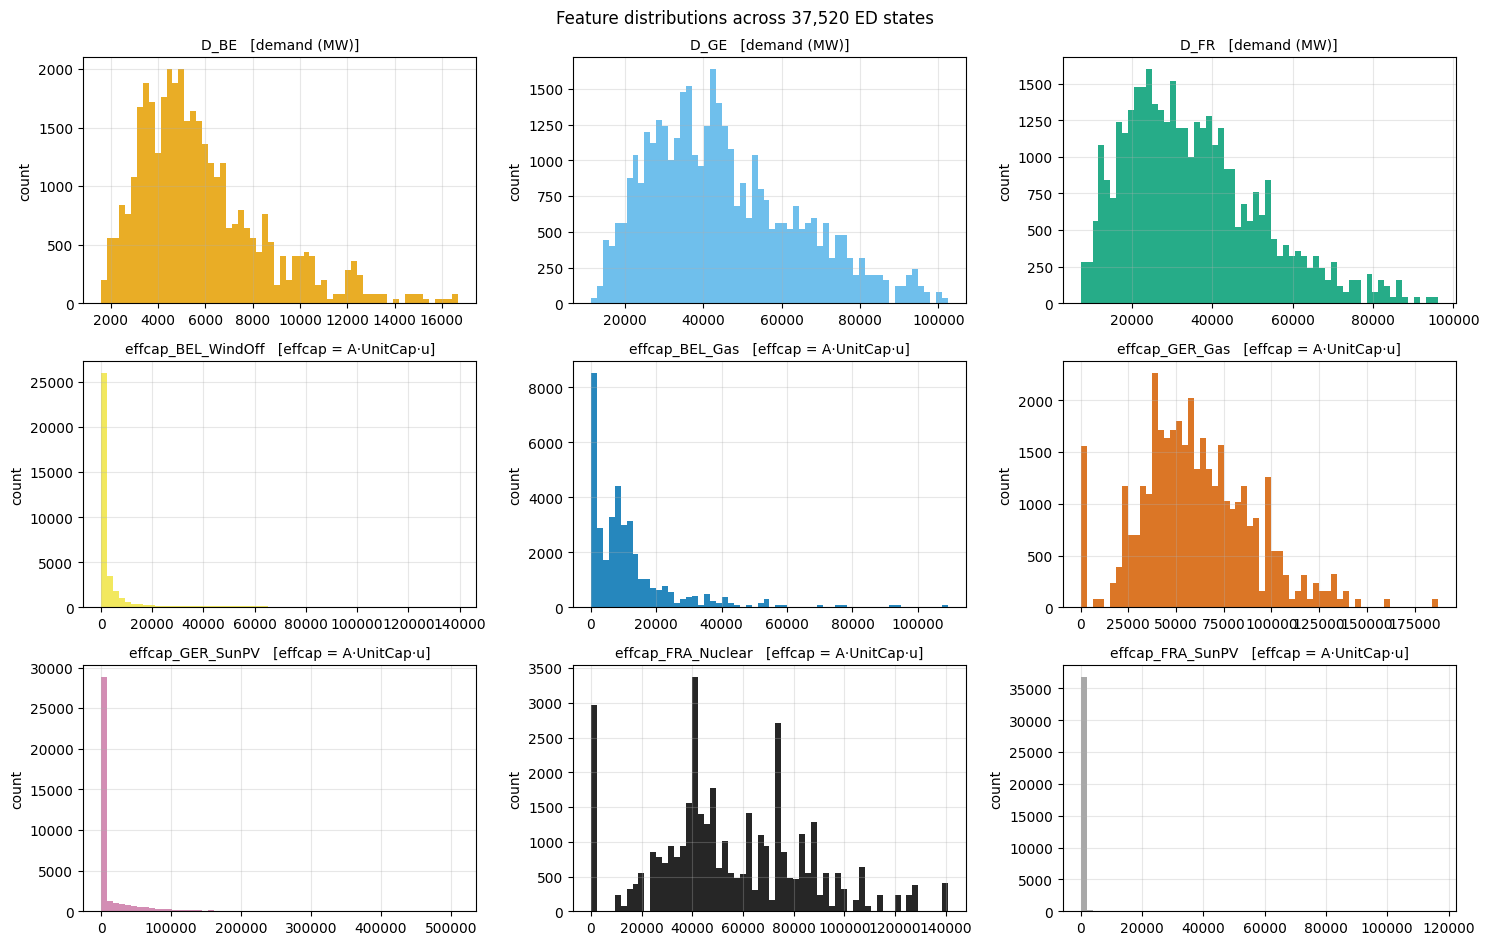

In [62]:
import matplotlib.pyplot as plt
import numpy as np, torch

X = ed_gen_data.X.numpy() if torch.is_tensor(ed_gen_data.X) else np.asarray(ed_gen_data.X)
G_names = [f"{c}_{t}" for (c, t) in ed_gen_data.G]
col_names = ["D_BE", "D_GE", "D_FR"] + [f"effcap_{g}" for g in G_names]

OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
             "#0072B2", "#D55E00", "#CC79A7", "#000000", "#999999"]

ncol = 3
nrow = int(np.ceil(X.shape[1] / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow))
axes = axes.ravel()

for j in range(X.shape[1]):
    ax = axes[j]
    ax.hist(X[:, j], bins=60, color=OKABE_ITO[j % len(OKABE_ITO)], alpha=0.85)
    kind = "demand (MW)" if j < 3 else "effcap = A·UnitCap·u"
    ax.set_title(f"{col_names[j]}   [{kind}]", fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylabel("count")

for k in range(X.shape[1], len(axes)):
    fig.delaxes(axes[k])

fig.suptitle(f"Feature distributions across {X.shape[0]:,} ED states", fontsize=12)
fig.tight_layout()
plt.show()

In [64]:
col = 8  # FRA_SunPV effcap
nz = X[:, col] > 1e-6
print("nonzero fraction:", nz.mean())
print("nonzero count:", nz.sum())
if nz.any():
    print("nonzero min/max/std:", X[nz, col].min(), X[nz, col].max(), X[nz, col].std())
else:
    print("no nonzero values at all")

nonzero fraction: 0.15605010660980811
nonzero count: 5855
nonzero min/max/std: 0.05 116549.55 8346.813383191513
